# import thư viện

In [16]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras

# import dữ liệu (keras)

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [18]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

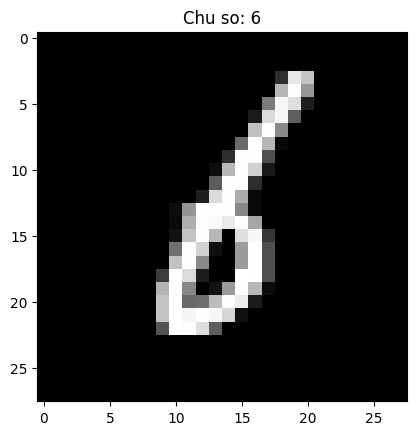

In [19]:
# xem thu hinh anh tap du lieu
import matplotlib.pyplot as plt
from PIL import Image

ind_data = 256
img = Image.fromarray(X_train[ind_data])
plt.imshow(img, cmap="gray")
plt.title("Chu so: " + str(y_train[ind_data]))
plt.show()

# Chuẩn hóa dữ liệu

In [20]:
# scale ma mau 0 -> 255 => [0, ..., 1]
X_train = X_train.astype("float64") / 255
X_test = X_test.astype("float64") / 255

X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

**Tham số cần lưu ý:**
- `n`: số hình (60000)
- `w`: chiều rộng (28)
- `h`: chiều cao (28)
- `d`: direction (vì hình trắng đen nên chọn **d = 1**, hình có màu RGB thì **d = 3**)
- `class`: số lớp (kết quả bao gồm các lớp với % khác nhau: [0: 1, 1: 00.0, ...])

In [21]:
# thêm chiều d
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)
X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [22]:
# them lop
my_classes = 10 # tu 0 -> 9
y_train = keras.utils.to_categorical(y_train, my_classes)
y_test = keras.utils.to_categorical(y_test, my_classes)
y_train.shape, y_test.shape

((60000, 10), (10000, 10))

# Huấn luyện mô hình

In [23]:
# khai bao mo hinh
input_shape = (28, 28, 1)
model = keras.Sequential([
    keras.layers.Conv2D(32, kernel_size=(3, 3), input_shape=input_shape),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    keras.layers.Conv2D(64, kernel_size=(3, 3)), # tang do phuc tap cho mo hinh
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    keras.layers.Flatten(), # chuyen 2D -> 1D
    keras.layers.Dense(my_classes, activation="softmax"), # lop output (phan lop)
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

c:\Users\diepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# hoc
batch_size = 128  # số lượng ảnh mẫu được xử lý mỗi lần mô hình cập nhật trọng số
epochs = 10  # số lần mô hình sẽ được huấn luyện trên toàn bộ tập dữ liệu
validation_split = 0.2  # phần trăm dữ liệu huấn luyện được sử dụng để đánh giá mô hình trong quá trình huấn luyện
model.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 30s 71ms/step - accuracy: 0.9100 - loss: 0.3232 - val_accuracy: 0.9686 - val_loss: 0.1124
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - accuracy: 0.9727 - loss: 0.0911 - val_accuracy: 0.9777 - val_loss: 0.0769
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 29s 77ms/step - accuracy: 0.9803 - loss: 0.0655 - val_accuracy: 0.9795 - val_loss: 0.0694
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 87ms/step - accuracy: 0.9831 - loss: 0.0555 - val_accuracy: 0.9822 - val_loss: 0.0616
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 30s 81ms/step - accuracy: 0.9855 - loss: 0.0474 - val_accuracy: 0.9843 - val_loss: 0.0572
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - accuracy: 0.9864 - loss: 0.0425 - val_accuracy: 0.9840 - val_loss: 0.0567
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 87ms/step - accuracy: 0.9894 - loss: 0.0363 - val_accuracy: 0.9817 - val_loss: 0.0695
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 86ms/step - accuracy: 0.9899 - loss: 0.0330 - 

# Đánh giá mô hình

In [28]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Độ chính xác trên tập kiểm tra: {accuracy:.4f}") # học được bao nhiều phần trăm từ dữ liệu
print(f"Độ mất mát trên tập kiểm tra: {loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9863 - loss: 0.0443
Độ chính xác trên tập kiểm tra: 0.9863
Độ mất mát trên tập kiểm tra: 0.0443


# Dự đoán mô hình

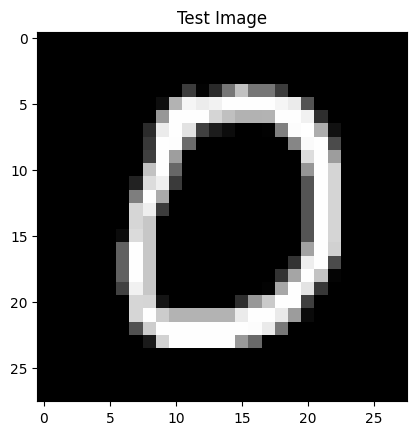

In [26]:
test_img = X_test[10]
# VE HINH ANH TEST
img = Image.fromarray((test_img.squeeze() * 255).astype('uint8'))
plt.imshow(img, cmap='gray')
plt.title("Test Image")
plt.show()

Vì layer Dense ở cuối có 10 units nên kết quả của predict cũng trả về một numpy array có 10 giá trị, mỗi giá trị là tỉ lệ mà hình thuộc lớp tương ứng.

> Ví dụ: Mô hình phân loại 4 lớp có kết quả predict là [0.1, 0.2, 0.7, 0.0] nghĩa là hình có 10% thuộc lớp thứ nhất, 20% thuộc lớp thứ hai, 70% thuộc lớp thứ ba và 0% thuộc lớp cuối cùng.

> Lưu ý: Tổng tất cả các tỉ lệ của mảng kết quả luôn bằng 1, tương ứng với 100%.

In [27]:
test_img = np.expand_dims(test_img, 0)
preds = model.predict(test_img)
print(preds)
test_pred = np.argmax(preds)
print(f"Predicted class = {test_pred}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
[[9.9999976e-01 1.0503761e-15 2.4047804e-07 4.7501105e-12 1.1364532e-19
  2.0099936e-11 2.9293890e-09 3.9940933e-12 2.7802677e-10 9.0206056e-09]]
Predicted class = 0
